In [1]:
# ==========================================
# LOAN PREDICTION - DATA PREPROCESSING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Install gdown
!pip install -q gdown

In [3]:
import gdown

file_id = "1bAHAPBDr0aTKeIScgDoFSwovESowMhBQ"

download_url = f"https://drive.google.com/uc?id={file_id}"

output_file = "loan_prediction.csv"

gdown.download(
    download_url,
    output_file,
    quiet=False
)

print("Dataset downloaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1bAHAPBDr0aTKeIScgDoFSwovESowMhBQ
To: /content/loan_prediction.csv
100%|██████████| 38.0k/38.0k [00:00<00:00, 33.3MB/s]

Dataset downloaded successfully.


In [4]:
df = pd.read_csv("loan_prediction.csv")

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Shape of Dataset: (614, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [6]:
display(df.head(10))

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [7]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
print("\nStatistical Summary:")
display(df.describe(include='all').T)


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP002990,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


In [9]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing_values)

,Missing Values,Percentage
Loan_ID,0,0.000000
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Education,0,0.000000
Self_Employed,32,5.211726
ApplicantIncome,0,0.000000
CoapplicantIncome,0,0.000000
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130


In [10]:
missing_values = missing_values[
    missing_values["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_values)

,Missing Values,Percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


In [11]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [12]:
for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(
            df[column].median()
        )

print("Numerical missing values handled.")

Numerical missing values handled.


In [13]:
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(
            df[column].mode()[0]
        )

print("Categorical missing values handled.")

Categorical missing values handled.


In [14]:
print("Total Missing Values After Treatment:")

print(df.isnull().sum().sum())

Total Missing Values After Treatment:
0


In [15]:
display(
    pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values
    })
)

,Column,Missing Values
0,Loan_ID,0
1,Gender,0
2,Married,0
3,Dependents,0
4,Education,0
5,Self_Employed,0
6,ApplicantIncome,0
7,CoapplicantIncome,0
8,LoanAmount,0
9,Loan_Amount_Term,0


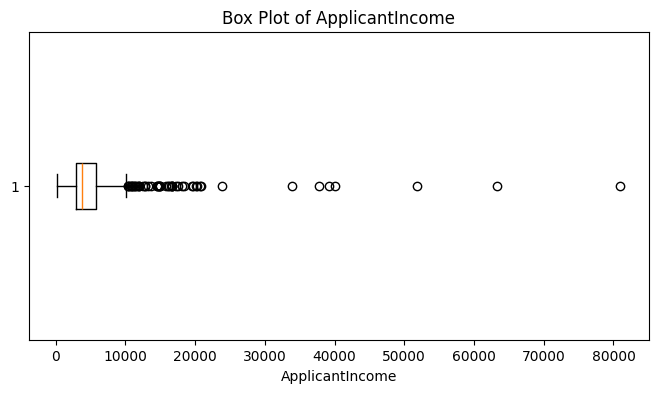

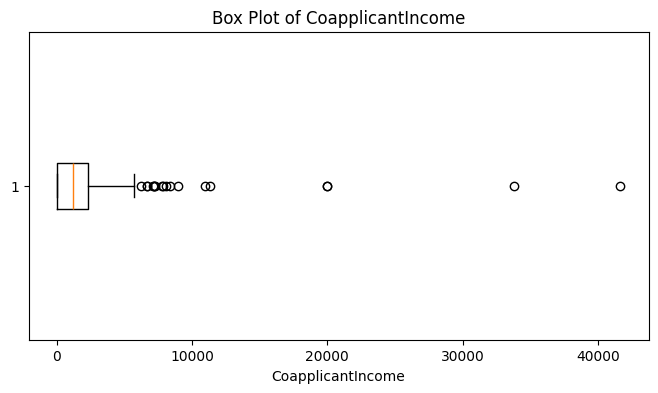

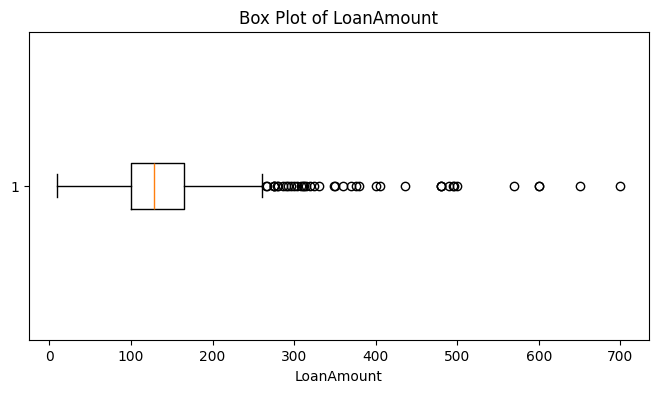

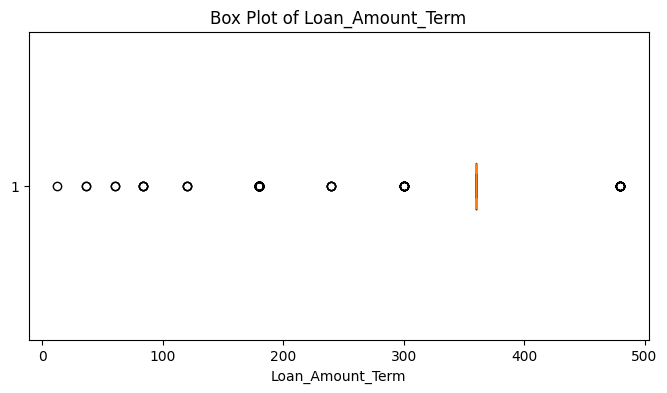

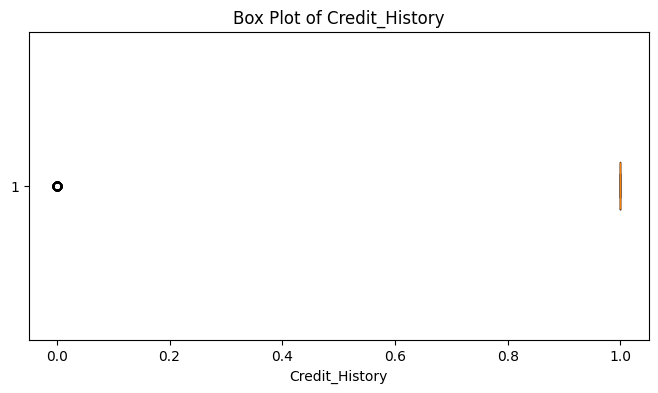

In [16]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.title(
        f"Box Plot of {column}"
    )

    plt.xlabel(column)

    plt.show()

In [17]:
outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

display(outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,ApplicantIncome,2877.50,5795.00,2917.50,-1498.750,10171.250,50
1,CoapplicantIncome,0.00,2297.25,2297.25,-3445.875,5743.125,18
2,LoanAmount,100.25,164.75,64.50,3.500,261.500,41
3,Loan_Amount_Term,360.00,360.00,0.00,360.000,360.000,88
4,Credit_History,1.00,1.00,0.00,1.000,1.000,89


In [18]:
df_outlier_treated = df.copy()

for column in numerical_columns:

    Q1 = df_outlier_treated[column].quantile(0.25)
    Q3 = df_outlier_treated[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_outlier_treated[column] = (
        df_outlier_treated[column]
        .clip(
            lower=lower_bound,
            upper=upper_bound
        )
    )

print("Outlier treatment completed.")

Outlier treatment completed.


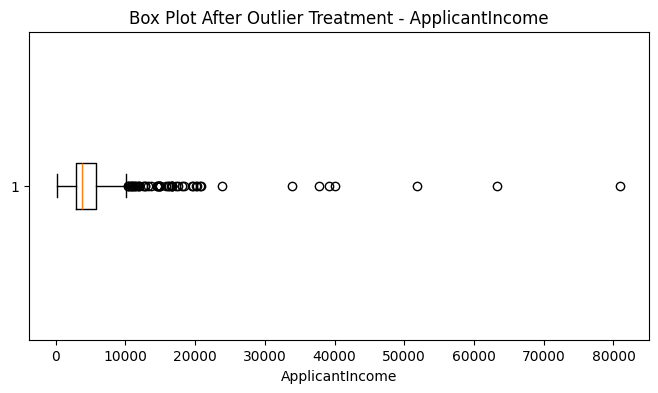

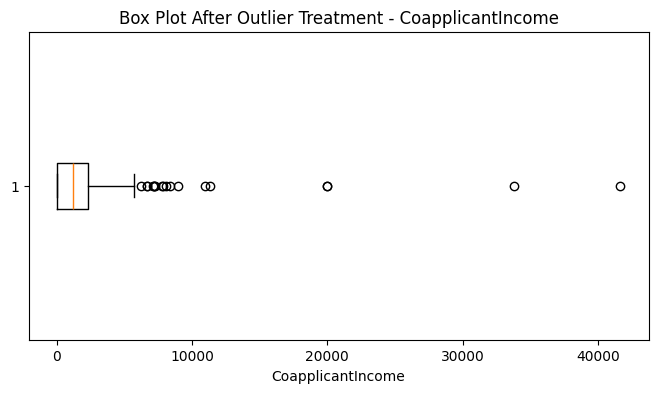

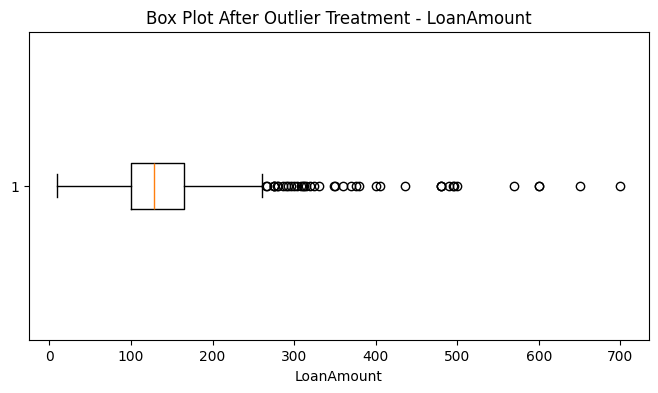

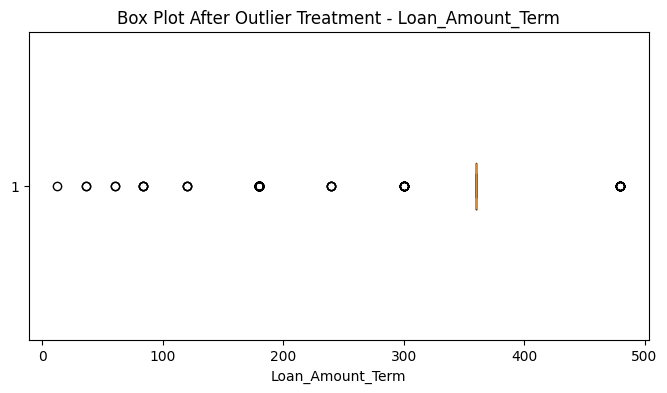

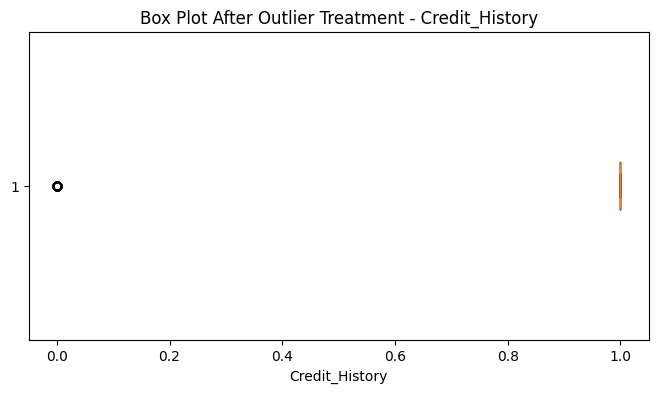

In [19]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column],
        vert=False
    )

    plt.title(
        f"Box Plot After Outlier Treatment - {column}"
    )

    plt.xlabel(column)

    plt.show()

In [20]:
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical Columns:")

print(categorical_columns)

Categorical Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [21]:
for column in categorical_columns:

    print(
        "\n",
        column,
        ":",
        df[column].unique()
    )


 Loan_ID : ['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP00

In [22]:
id_columns = [
    col for col in df.columns
    if 'id' in col.lower()
]

print("Possible ID Columns:", id_columns)

Possible ID Columns: ['Loan_ID']


In [23]:
if 'Loan_ID' in df.columns:

    df.drop(
        columns=['Loan_ID'],
        inplace=True
    )

    print("Loan_ID removed.")

Loan_ID removed.


In [24]:
if 'Loan_Status' in df.columns:

    print(
        "Loan_Status values before encoding:",
        df['Loan_Status'].unique()
    )

    df['Loan_Status'] = (
        df['Loan_Status']
        .astype(str)
        .str.strip()
        .map({
            'Y': 1,
            'N': 0,
            'Yes': 1,
            'No': 0
        })
    )

    print(
        "Loan_Status values after encoding:",
        df['Loan_Status'].unique()
    )

Loan_Status values before encoding: ['Y' 'N']
Loan_Status values after encoding: [1 0]


In [25]:
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(categorical_columns)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [26]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print(
    "Dataset Shape After Encoding:",
    df_encoded.shape
)

display(df_encoded.head())

Dataset Shape After Encoding: (614, 15)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,1,0,0,0,0,0,0,0,1
1,4583,1508.0,128.0,360.0,1.0,0,1,1,1,0,0,0,0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1,1,0,0,0,0,1,0,1
3,2583,2358.0,120.0,360.0,1.0,1,1,1,0,0,0,1,0,0,1
4,6000,0.0,141.0,360.0,1.0,1,1,0,0,0,0,0,0,0,1


In [27]:
target_column = "Loan_Status"

X = df_encoded.drop(
    columns=[target_column]
)

y = df_encoded[target_column]

print(
    "Feature Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)

Feature Shape: (614, 14)
Target Shape: (614,)


In [28]:
continuous_columns = [
    col for col in X.columns
    if X[col].nunique() > 2
]

print(
    "Columns Selected for Scaling:"
)

print(continuous_columns)

Columns Selected for Scaling:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']


In [29]:
scaler = StandardScaler()

X_scaled = X.copy()

X_scaled[
    continuous_columns
] = scaler.fit_transform(
    X[continuous_columns]
)

display(X_scaled.head())

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,-0.211241,0.273231,1.0,1,0,0,0,0,0,0,0,1
1,-0.134412,-0.038732,-0.211241,0.273231,1.0,1,1,1,0,0,0,0,0,0
2,-0.393747,-0.554487,-0.948996,0.273231,1.0,1,1,0,0,0,0,1,0,1
3,-0.462062,0.251980,-0.306435,0.273231,1.0,1,1,0,0,0,1,0,0,1
4,0.097728,-0.554487,-0.056551,0.273231,1.0,1,0,0,0,0,0,0,0,1


In [30]:
display(
    X_scaled[
        continuous_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,-4.339634e-18,1.000815,-0.860649,-0.413816,-0.260639,0.064144,12.384623
CoapplicantIncome,614.0,4.050325e-17,1.000815,-0.554487,-0.554487,-0.148005,0.231202,13.696173
LoanAmount,614.0,-2.603780e-17,1.000815,-1.627255,-0.541446,-0.211241,0.226057,6.595146
Loan_Amount_Term,614.0,5.930833e-17,1.000815,-5.132498,0.273231,0.273231,0.273231,2.137276


In [31]:
final_df = X_scaled.copy()

final_df[
    target_column
] = y.values

print(
    "Final Dataset Shape:",
    final_df.shape
)

display(final_df.head(10))

Final Dataset Shape: (614, 15)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,0.072991,-0.554487,-0.211241,0.273231,1.0,1,0,0,0,0,0,0,0,1,1
1,-0.134412,-0.038732,-0.211241,0.273231,1.0,1,1,1,0,0,0,0,0,0,0
2,-0.393747,-0.554487,-0.948996,0.273231,1.0,1,1,0,0,0,0,1,0,1,1
3,-0.462062,0.251980,-0.306435,0.273231,1.0,1,1,0,0,0,1,0,0,1,1
4,0.097728,-0.554487,-0.056551,0.273231,1.0,1,0,0,0,0,0,0,0,1,1
5,0.002218,0.880600,1.442758,0.273231,1.0,1,1,0,1,0,0,1,0,1,1
6,-0.503019,-0.035995,-0.603917,0.273231,1.0,1,1,0,0,0,1,0,0,1,1
7,-0.387850,0.301914,0.145737,0.273231,0.0,1,1,0,0,1,0,0,1,0,0
8,-0.228939,-0.032575,0.264730,0.273231,1.0,1,1,0,1,0,0,0,0,1,1
9,1.218457,3.196713,2.418499,0.273231,1.0,1,1,1,0,0,0,0,1,0,0


In [32]:
print(
    "Missing Values in Final Dataset:",
    final_df.isnull().sum().sum()
)

Missing Values in Final Dataset: 0


In [33]:
print("\nFinal Dataset Information:")

final_df.info()


Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          614 non-null    float64
 1   CoapplicantIncome        614 non-null    float64
 2   LoanAmount               614 non-null    float64
 3   Loan_Amount_Term         614 non-null    float64
 4   Credit_History           614 non-null    float64
 5   Gender_Male              614 non-null    int64  
 6   Married_Yes              614 non-null    int64  
 7   Dependents_1             614 non-null    int64  
 8   Dependents_2             614 non-null    int64  
 9   Dependents_3+            614 non-null    int64  
 10  Education_Not Graduate   614 non-null    int64  
 11  Self_Employed_Yes        614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
 14

In [34]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print(
    "Final number of rows:",
    final_df.shape[0]
)

print(
    "Final number of columns:",
    final_df.shape[1]
)

print(
    "Missing values:",
    final_df.isnull().sum().sum()
)

print(
    "Duplicate records:",
    final_df.duplicated().sum()
)

PREPROCESSING SUMMARY
Final number of rows: 614
Final number of columns: 15
Missing values: 0
Duplicate records: 0


In [35]:
final_df.to_csv(
    "loan_prediction_preprocessed.csv",
    index=False
)

print(
    "Preprocessed dataset saved successfully."
)

Preprocessed dataset saved successfully.
